# Breast Cancer Wisconsin — Data Cleaning & Feature Engineering

In this notebook we apply the cleaning pipeline from `utils.py`:

1. Drop the patient ID column
2. Encode `diagnosis` (M -> 1, B -> 0)
3. Engineer ratio features (`*_worst_to_mean`) and a size composite
4. Save the cleaned dataset to `data/breast_cancer_cleaned.csv`

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (
    load_data, drop_id, encode_diagnosis, create_features, preprocess_data,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/breast_cancer.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Missing / Invalid Values

In [3]:
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")
print(f"Duplicate rows      : {df.duplicated().sum()}")

Total missing values: 0
Duplicate rows      : 0


## 3. Drop ID and Encode Target

In [4]:
df_clean = drop_id(df)
df_clean = encode_diagnosis(df_clean)
print(f"After dropping ID + encoding: {df_clean.shape}")
print("Diagnosis distribution:")
print(df_clean["diagnosis"].value_counts())
df_clean.head()

After dropping ID + encoding: (569, 31)
Diagnosis distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Distribution Check Before Feature Engineering

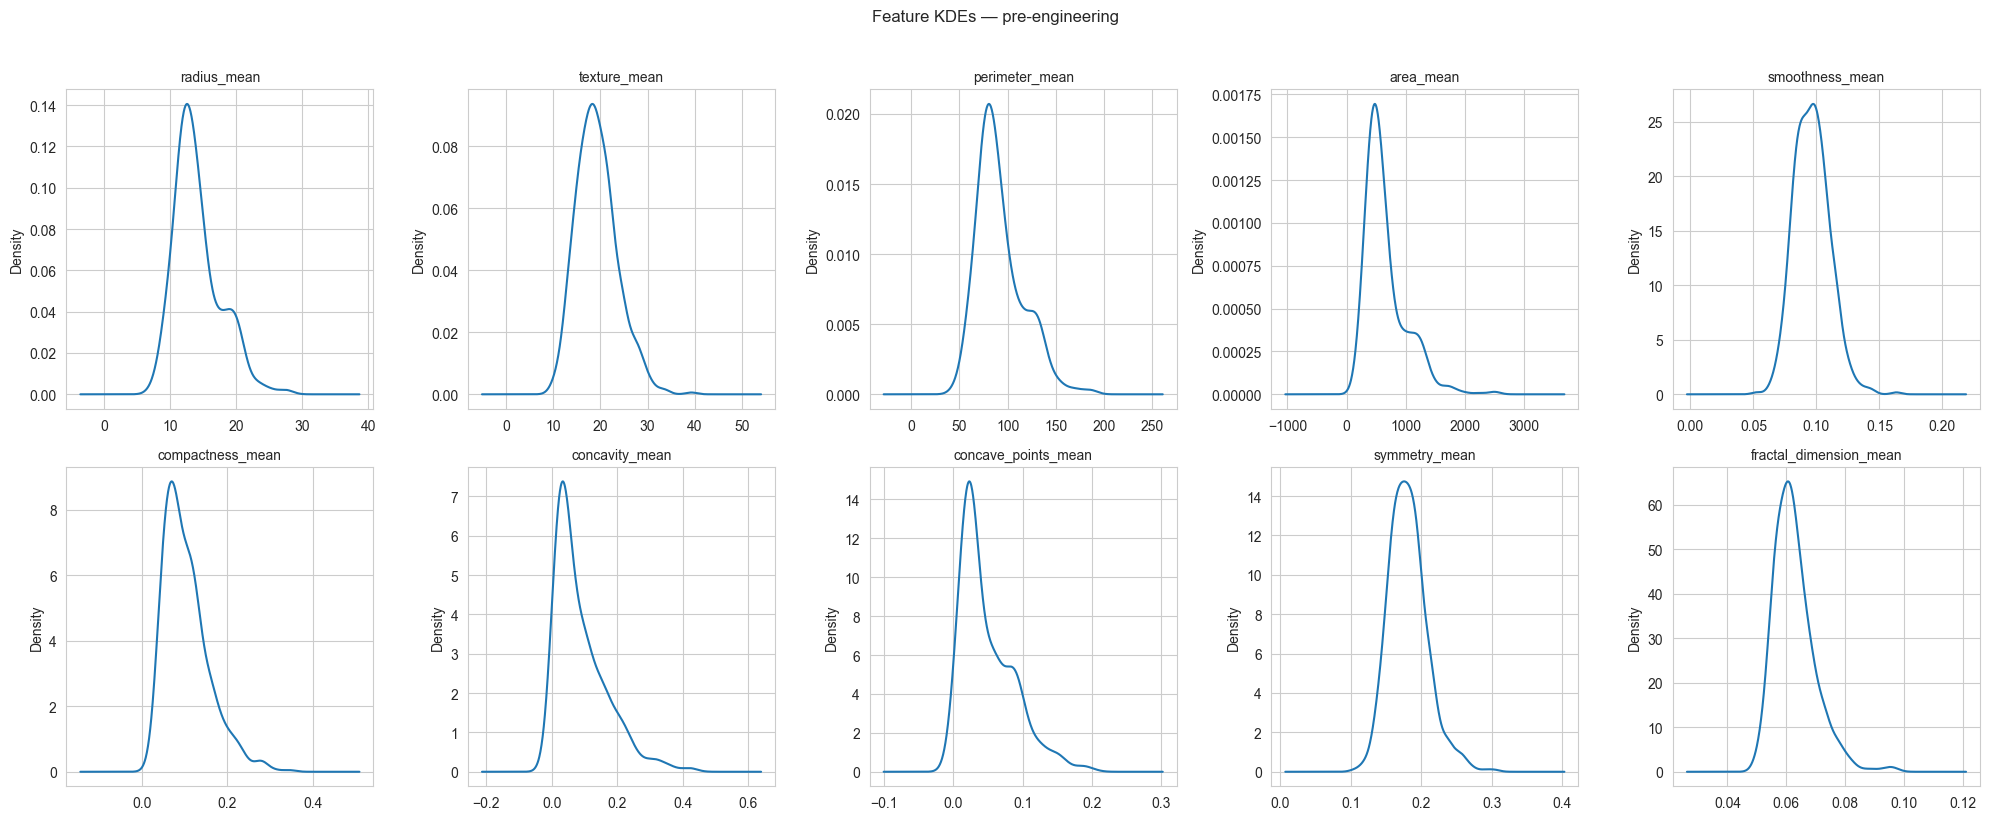

In [5]:
mean_features = [c for c in df_clean.columns if c.endswith("_mean")]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(mean_features):
    df_clean[col].plot(kind="kde", ax=axes[i])
    axes[i].set_title(col, fontsize=10)
plt.suptitle("Feature KDEs — pre-engineering", y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

We add 11 new features:
- 10 `*_worst_to_mean` ratios that capture how extreme the worst region of a tumor is.
- 1 `size_composite = radius_mean * perimeter_mean` summarising overall tumor size.

In [6]:
df_feat = create_features(df_clean)
new_cols = [c for c in df_feat.columns if c not in df_clean.columns]
print(f"New features ({len(new_cols)}):")
for c in new_cols:
    print(f"  {c}")
df_feat.head()

New features (11):
  radius_worst_to_mean
  texture_worst_to_mean
  perimeter_worst_to_mean
  area_worst_to_mean
  smoothness_worst_to_mean
  compactness_worst_to_mean
  concavity_worst_to_mean
  concave_points_worst_to_mean
  symmetry_worst_to_mean
  fractal_dimension_worst_to_mean
  size_composite


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,texture_worst_to_mean,perimeter_worst_to_mean,area_worst_to_mean,smoothness_worst_to_mean,compactness_worst_to_mean,concavity_worst_to_mean,concave_points_worst_to_mean,symmetry_worst_to_mean,fractal_dimension_worst_to_mean,size_composite
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,1.669557,1.503257,2.016983,1.369932,2.397695,2.372209,1.804215,1.902026,1.510609,2209.1720
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,1.317389,1.194883,1.475113,1.460939,2.372838,2.780207,2.650705,1.517660,1.570849,2733.7530
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,1.201412,1.173077,1.420615,1.317518,2.654784,2.281662,1.899922,1.746254,1.459910,2559.7000
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,1.300294,1.274426,1.470344,1.472281,3.051427,2.845485,2.447719,2.556026,1.775452,885.9636
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,1.162483,1.126573,1.214341,1.369890,1.543675,2.020202,1.558006,1.306799,1.305116,2741.1790


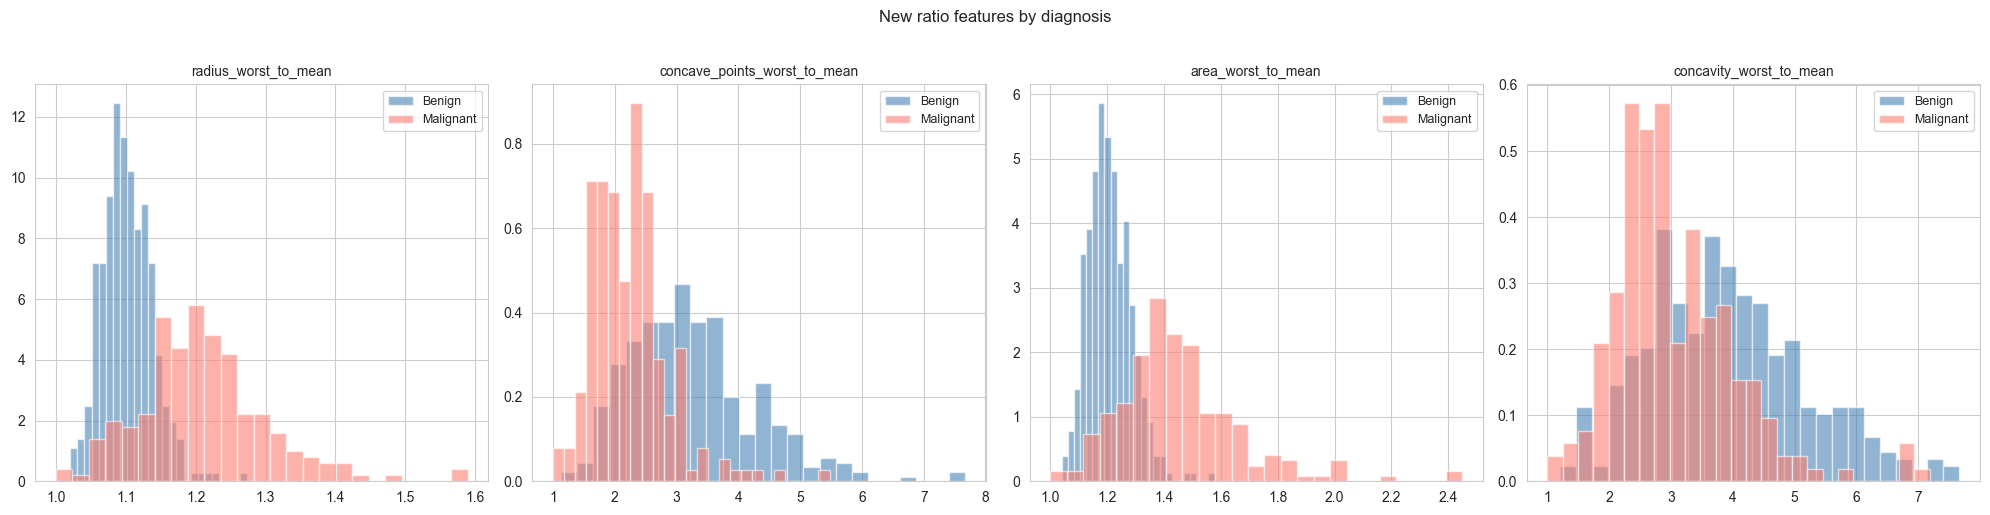

In [7]:
# Visualize a few new ratio features split by diagnosis
ratios = ["radius_worst_to_mean", "concave_points_worst_to_mean",
          "area_worst_to_mean", "concavity_worst_to_mean"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(ratios):
    for diag, color, label in [(0, "steelblue", "Benign"), (1, "salmon", "Malignant")]:
        subset = df_feat[df_feat["diagnosis"] == diag][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=9)
plt.suptitle("New ratio features by diagnosis", y=1.02)
plt.tight_layout()
plt.show()

## 6. Run the Full Pipeline

In [8]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (569, 42)
Missing values : 0


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,texture_worst_to_mean,perimeter_worst_to_mean,area_worst_to_mean,smoothness_worst_to_mean,compactness_worst_to_mean,concavity_worst_to_mean,concave_points_worst_to_mean,symmetry_worst_to_mean,fractal_dimension_worst_to_mean,size_composite
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,1.669557,1.503257,2.016983,1.369932,2.397695,2.372209,1.804215,1.902026,1.510609,2209.1720
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,1.317389,1.194883,1.475113,1.460939,2.372838,2.780207,2.650705,1.517660,1.570849,2733.7530
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,1.201412,1.173077,1.420615,1.317518,2.654784,2.281662,1.899922,1.746254,1.459910,2559.7000
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,1.300294,1.274426,1.470344,1.472281,3.051427,2.845485,2.447719,2.556026,1.775452,885.9636
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,1.162483,1.126573,1.214341,1.369890,1.543675,2.020202,1.558006,1.306799,1.305116,2741.1790


## 7. Sanity Checks & Save

In [9]:
assert df_processed["diagnosis"].isin([0, 1]).all()
assert df_processed.isnull().sum().sum() == 0
assert "id" not in df_processed.columns
print("All checks passed.")

All checks passed.


In [10]:
df_processed.to_csv("data/breast_cancer_cleaned.csv", index=False)
print(f"Saved data/breast_cancer_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/breast_cancer_cleaned.csv (569 rows, 42 cols)
